# Scam Detection AI - Exploratory Data Analysis

This notebook analyzes the consolidated dataset across all phases (Phase 1.5 Text and Phase 2 Audio Transcripts) to justify the architectural decisions made during the project.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import warnings
warnings.filterWarning('ignore') if hasattr(warnings, 'filterWarning') else warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Data Loading
We load the programmatically collated mega-dataset containing both written text and spoken ASR transcripts.

In [2]:
# Note: Ensure data/collated_for_eda.csv is downloaded from DagsHub S3 if running remotely.
# For local execution, we load the locally cached file.
df = pd.read_csv("data/collated_for_eda.csv")
print(f"Total samples: {len(df)}")
df.head()

Total samples: 31522


,text,label,source_phase
0,"hello. hello, this is karen from speedy delive...",0,Phase_1_and_1.5_Written_Text
1,"""your child is in my hands. if you don't want ...",1,Phase_1_and_1.5_Written_Text
2,'i am your transportation consulting assistant...,1,Phase_1_and_1.5_Written_Text
3,"didn't try, g and i decided not to head out",0,Phase_1_and_1.5_Written_Text
4,i know what you want to say.,0,Phase_1_and_1.5_Written_Text


## 2. Label Balance by Phase
It is critical that both our written training corpus and our spoken evaluation corpus remain balanced to prevent model bias.

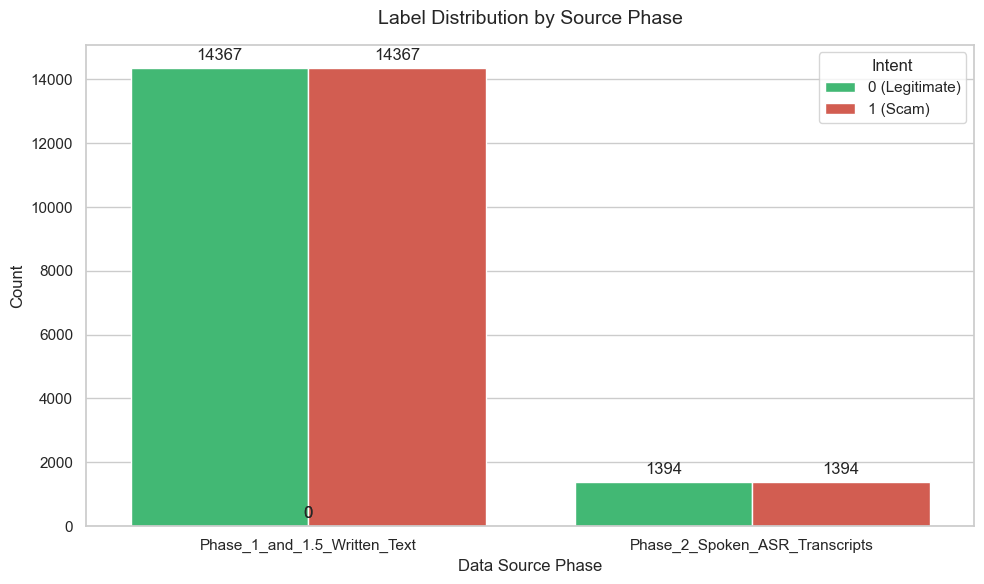

In [3]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='source_phase', hue='label', palette=['#2ecc71', '#e74c3c'])
plt.title('Label Distribution by Source Phase', fontsize=14, pad=15)
plt.xlabel('Data Source Phase', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Intent', labels=['0 (Legitimate)', '1 (Scam)'])

# Add counts on top of bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')
plt.tight_layout()
os.makedirs("output/eda_plots", exist_ok=True)
plt.savefig("output/eda_plots/label_balance.png", dpi=300)
plt.show()

## 3. Text Length Distribution (Word Count)
**Architectural Justification:** The DistilBERT baseline (Stage 1) had a strict 512-token context limit. By visualizing the word counts of Phase 2 ASR transcripts, we can prove why upgrading to the 8192-token ModernBERT model (Stage 1.5) was absolutely necessary for the audio pipeline.

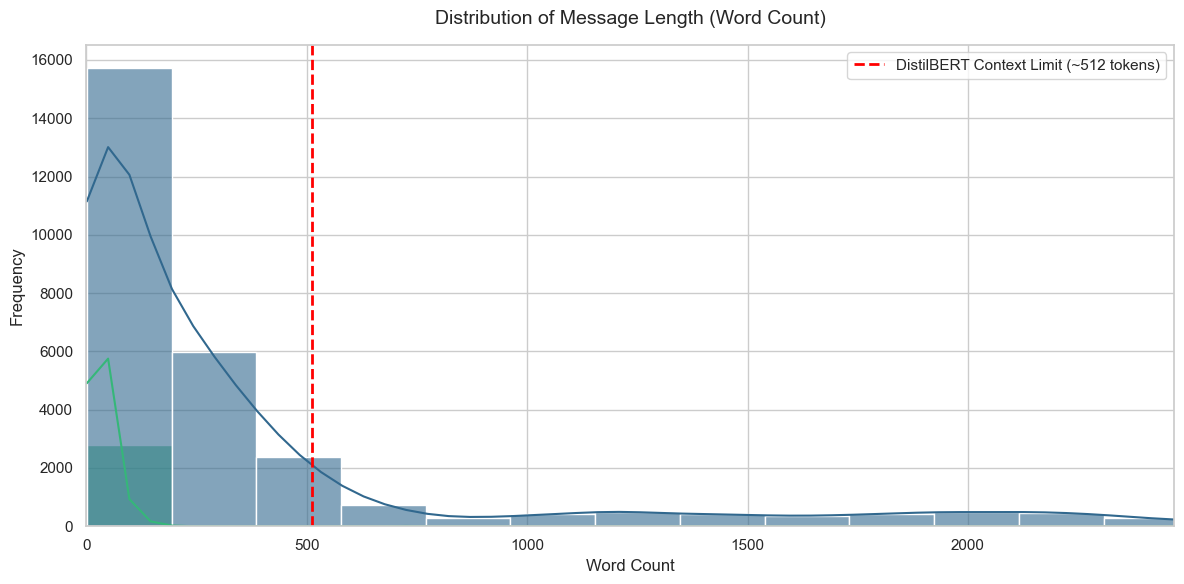

In [4]:
df['word_count'] = df['text'].astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='word_count', hue='source_phase', bins=50, kde=True, palette='viridis', alpha=0.6)
plt.axvline(x=512, color='red', linestyle='--', linewidth=2, label='DistilBERT Context Limit (~512 tokens)')
plt.title('Distribution of Message Length (Word Count)', fontsize=14, pad=15)
plt.xlabel('Word Count', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xlim(0, max(df['word_count'].quantile(0.99), 1000)) # Focus on 99th percentile
plt.legend()
plt.tight_layout()
plt.savefig("output/eda_plots/length_distribution.png", dpi=300)
plt.show()

## 4. Lexical Disfluency Analysis (Domain Gap)
**Domain Adaptation Justification:** Written text (emails/SMS) lacks conversational filler words. Spoken phone calls rely heavily on disfluencies (uh, um, like). This analysis quantifies the domain gap that necessitated the Phase 2 transcript retraining.

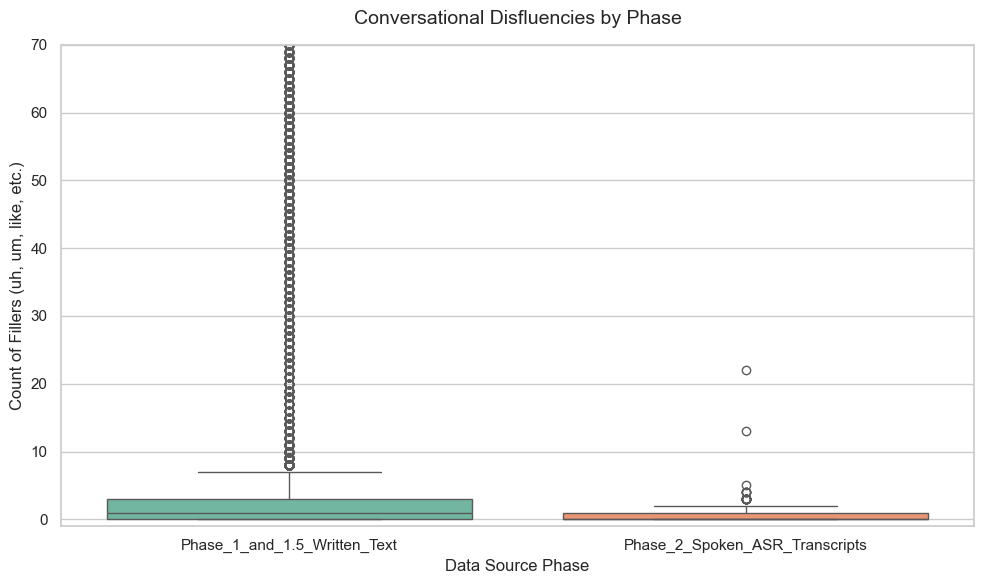

In [5]:
import re
def count_disfluencies(text):
    text = str(text).lower()
    # Simple regex to count occurrences of common conversational fillers
    fillers = r'\b(uh|um|hmm|ah|like|so)\b'
    return len(re.findall(fillers, text))

df['disfluency_count'] = df['text'].apply(count_disfluencies)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='source_phase', y='disfluency_count', palette='Set2')
plt.title('Conversational Disfluencies by Phase', fontsize=14, pad=15)
plt.xlabel('Data Source Phase', fontsize=12)
plt.ylabel('Count of Fillers (uh, um, like, etc.)', fontsize=12)
# Limit Y axis to show the boxplot clearly without extreme outliers skewing it
plt.ylim(-1, df['disfluency_count'].quantile(0.95) + 5)
plt.tight_layout()
plt.savefig("output/eda_plots/disfluency_boxplot.png", dpi=300)
plt.show()